Places where we can ge embedding models:
1. Huggingface Hub
2. OpenAI SDK(Lang-chain)
2. Gemini SDK(Lang-chain)

In [1]:
# Set Environment Variables for Hugging Face and Google Gemini Pro API
import os
os.environ["HF_TOKEN"] = os.getenv("HF_TOKEN")
os.environ["GOOGLE_API_KEY"] = os.getenv("GOOGLE_API_KEY")

## Transformer Based Embedding Models:

We can convert Text, Audio, Image, Video data into embedding.

In [2]:
from sentence_transformers import SentenceTransformer

d:\Coding\Full-Stack-GenAI-AgenticAI-Bootcamp\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Load the pre-trained model
open_source_embedding_model = SentenceTransformer('all-MiniLM-L6-v2')

#### Converting word to Embedding

In [4]:
text = "machine"

In [5]:
# Encode the text to get its embedding
embedding = open_source_embedding_model.encode(text)

In [6]:
# Diemension of the embedding vector
len(embedding)

384

#### Converting Sentence to Embedding

In [7]:
sent = "how to reduce heart disease risk?"

In [8]:
sent_embedding = open_source_embedding_model.encode(sent)

In [9]:
len(sent_embedding)

384

#### Converting Paragraph to Embedding

In [10]:
paragraph = """
Machine learning is a field of artificial intelligence that focuses on building systems 
that learn from data. It is widely used in applications like recommendation systems, 
image recognition, and natural language processing.
"""

In [11]:
paragraph_embedding = open_source_embedding_model.encode(paragraph)

In [12]:
len(paragraph_embedding)

384

### Google Gemini Models

In [14]:
from langchain_google_genai import GoogleGenerativeAIEmbeddings

In [19]:
# Import model
google_embedding_model = GoogleGenerativeAIEmbeddings(model="gemini-embedding-001")

In [22]:
# Get embedding for a query
embedding = google_embedding_model.embed_query("What is the capital of France?")

In [24]:
# length/dimension of the embedding vector
len(embedding)

3072

#### Converting Image to Embedding

ViT(vision transformer) and CLIP(contrastive language-image pretraining) are two popular <br>transformer-based open source models used for image processing tasks.

In [33]:
from transformers import CLIPModel, CLIPProcessor
import torch

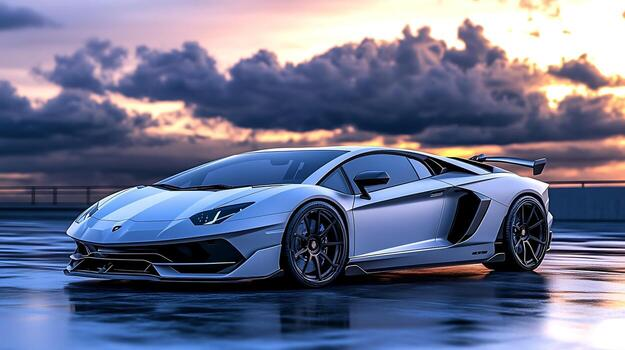

In [29]:
# read the image
from PIL import Image
image = Image.open("D:\\Coding\\Full-Stack-GenAI-AgenticAI-Bootcamp\\02_Transformers\\image\\car.png")
image

In [30]:
# import model and processor
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

d:\Coding\Full-Stack-GenAI-AgenticAI-Bootcamp\.venv\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\ahmad\.cache\huggingface\hub\models--openai--clip-vit-base-patch32. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling

In [31]:
# preprocess the image
inputs = processor(images=image, return_tensors="pt")

In [34]:
# pass the preprocessed image through the model to get the image embedding
with torch.no_grad():
    image_embedding = model.get_image_features(**inputs)

In [35]:
image_embedding

tensor([[ 1.7451e-01,  4.0925e-02, -7.4784e-01,  1.1893e-01,  4.9605e-02,
         -2.8110e-01,  7.1996e-02, -1.1597e-01,  6.8297e-01, -4.1004e-02,
          2.2749e-01,  1.0617e-01,  1.5319e-02, -2.9485e-01,  9.1500e-01,
          1.4324e-01,  1.4086e+00, -1.6573e-01,  1.4875e-01, -2.4321e-01,
         -1.5027e-02,  1.4346e-01, -5.0841e-02,  1.0487e-01, -4.6231e-01,
          4.5388e-01, -3.7032e-03, -3.8805e-02,  1.2599e-01,  2.1929e-01,
         -1.1085e-01, -3.5469e-01,  3.7769e-01, -4.3610e-01,  9.5427e-02,
         -1.9101e-01,  2.4926e-01,  1.6689e-01,  1.4734e-01,  1.4259e+00,
          1.5225e-01,  2.9350e-01,  3.1035e-01, -1.9869e-01,  2.0045e-01,
          1.7430e-01, -8.2419e-02, -1.3504e-01,  3.8600e-01, -1.9551e-01,
         -4.3297e-01, -9.6327e-02,  2.7468e-03,  1.5661e-01, -2.0174e-01,
         -4.2512e-01,  2.1314e-01, -6.8133e-02, -1.1183e+00, -6.5931e-01,
         -4.5497e-01, -1.2612e-01, -4.4117e-01,  9.8761e-02, -4.4140e-01,
         -2.7653e-01, -1.5544e-01, -6.

## Semantic Search (Similarity Search)

 🔹 Cosine Similarity
- Higher value = more similar  
- **Range:** `-1 to 1`

 🔹 Dot Product
- Higher value = more similar  
- Depends on vector magnitude  
- **Range:** `-∞ to +∞`

 🔹 Euclidean Distance
- Lower value = more similar  
- **Range:** `0 to +∞`

In [42]:
# Formula for dot product of two vectors a and b
def dot_product(a, b):
    return np.dot(a, b)

In [43]:
# Formula for cosine similarity of two vectors a and b
def cosine_similarity(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

In [44]:
# Formula for euclidean distance of two vectors a and b
def euclidean_distance(a, b):
    a = np.array(a)
    b = np.array(b)
    return np.linalg.norm(a - b)

Find Similarity between query and documents

In [46]:
query = "How to reduce heart disease risk?"

In [47]:
documents = [
    "Eating fiber reduces heart risk.",
    "Fruits and vegetables lower cardiovascular disease chances.",
    "Buying a new car improves driving comfort.",
    "Regular exercise improves heart health."
]

In [49]:
# Convert query and documents to embeddings
query_embedding = google_embedding_model.embed_query(query)
document_embeddings = google_embedding_model.embed_documents(documents)

In [51]:
# Sentencess in the documents
len(document_embeddings)

4

In [52]:
# Dimension of each sentence of the documents
len(document_embeddings[0])

3072

In [53]:
import numpy as np

In [56]:
# Similarity scores between query and documents
results = []

for doc, doc_emb in zip(documents, document_embeddings):
    results.append({
        "query": query,
        "document": doc,
        "cosine": cosine_similarity(query_embedding, doc_emb),
        "dot_product": dot_product(query_embedding, doc_emb),
        "euclidean": euclidean_distance(query_embedding, doc_emb)
    })

results

[{'query': 'How to reduce heart disease risk?',
  'document': 'Eating fiber reduces heart risk.',
  'cosine': 0.7395238839381588,
  'dot_product': 0.739523906997596,
  'euclidean': 0.7217702185375451},
 {'query': 'How to reduce heart disease risk?',
  'document': 'Fruits and vegetables lower cardiovascular disease chances.',
  'cosine': 0.7132289221700367,
  'dot_product': 0.7132289415495632,
  'euclidean': 0.7573256705301548},
 {'query': 'How to reduce heart disease risk?',
  'document': 'Buying a new car improves driving comfort.',
  'cosine': 0.5761824193919589,
  'dot_product': 0.5761824550973114,
  'euclidean': 0.9206710670717551},
 {'query': 'How to reduce heart disease risk?',
  'document': 'Regular exercise improves heart health.',
  'cosine': 0.7141669909372163,
  'dot_product': 0.71416708248218,
  'euclidean': 0.7560860343930161}]

## Keyword Search

In [57]:
documents

['Eating fiber reduces heart risk.',
 'Fruits and vegetables lower cardiovascular disease chances.',
 'Buying a new car improves driving comfort.',
 'Regular exercise improves heart health.']

In [58]:
query

'How to reduce heart disease risk?'

In [59]:
from collections import Counter

In [64]:
# Preprocess the query by converting to lowercase, removing punctuation, and splitting into words
query_words = query.lower().replace("?", "").split()
query_words

['how', 'to', 'reduce', 'heart', 'disease', 'risk']

In [61]:
documents[0]

'Eating fiber reduces heart risk.'

In [63]:
# Preprocess the first document by converting to lowercase, removing punctuation, and splitting into words
doc_words = documents[0].lower().replace(".", "").split()
doc_words

['eating', 'fiber', 'reduces', 'heart', 'risk']

In [67]:
# Count the frequency of each word in the first document
doc_count = Counter(doc_words)
doc_count

Counter({'eating': 1, 'fiber': 1, 'reduces': 1, 'heart': 1, 'risk': 1})

In [68]:
# Print the frequency of each query word in the first document
for word in query_words:
    print(f"{word}: {doc_count[word]}")

how: 0
to: 0
reduce: 0
heart: 1
disease: 0
risk: 1


In [70]:
score = sum(doc_count[word] for word in query_words) 
score

2

Score = number of matching words

In [71]:
# Function to perform keyword search and rank documents based on the frequency of query words
def keyword_search(query, documents):
    query_words = query.lower().replace("?", "").split()
    results = []

    for doc in documents:
        doc_words = doc.lower().replace(".", "").split()
        doc_count = Counter(doc_words)

        score = sum(doc_count[word] for word in query_words) 
        results.append((doc, score))

    return sorted(results, key=lambda x: x[1], reverse=True)

In [72]:
keyword_results = keyword_search(query, documents)
keyword_results

[('Eating fiber reduces heart risk.', 2),
 ('Fruits and vegetables lower cardiovascular disease chances.', 1),
 ('Regular exercise improves heart health.', 1),
 ('Buying a new car improves driving comfort.', 0)]